In [1]:
import subprocess, sys

required = [
    'numpy', 'pandas', 'matplotlib', 'seaborn',
    'Pillow', 'scikit-learn', 'torch', 'torchvision', 'tqdm'
]

for pkg in required:
    try:
        __import__(pkg.lower().replace('-','_').replace('pillow','PIL').replace('scikit_learn','sklearn'))
        print(f'  ✓ {pkg}')
    except ImportError:
        print(f'  installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  ✓ {pkg} installed')

print('\nAll dependencies ready.')

  ✓ numpy
  ✓ pandas
  ✓ matplotlib
  ✓ seaborn
  ✓ Pillow
  ✓ scikit-learn
  installing torch...
  ✓ torch installed
  installing torchvision...
  ✓ torchvision installed
  ✓ tqdm

All dependencies ready.


## Imports and Configuration

In [ ]:
import os, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch device: {DEVICE}')
print(f'NumPy: {np.__version__} | Torch: {torch.__version__}')

PyTorch device: cpu
NumPy: 1.26.4 | Torch: 2.10.0+cpu


## Data Loading & EDA

In [ ]:
BASE_DIR = Path('Orange Dataset')   
if not BASE_DIR.exists():
    import zipfile, glob
    zips = glob.glob('*.zip') + glob.glob('**/*.zip', recursive=True)
    if zips:
        print(f'Extracting {zips[0]} ...')
        with zipfile.ZipFile(zips[0]) as z:
            z.extractall('.')
        candidates = [p for p in Path('.').iterdir() if p.is_dir() and 'orange' in p.name.lower()]
        if candidates:
            BASE_DIR = candidates[0]
    else:
        raise FileNotFoundError(
            f'Dataset folder not found at "{BASE_DIR}". '
            'Place "Orange Dataset" folder (or zip) next to this notebook.'
        )

print(f'Dataset root: {BASE_DIR.resolve()}')

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
rows = []
for split in ['train', 'test']:
    split_dir = BASE_DIR / split
    if not split_dir.exists():
        continue
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        for img_path in class_dir.iterdir():
            if img_path.suffix.lower() in IMG_EXTS:
                rows.append({'split': split, 'label': class_dir.name, 'path': str(img_path)})

df_imgs = pd.DataFrame(rows)
LABELS = sorted(df_imgs['label'].unique())
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

print(f'\nTotal images: {len(df_imgs)}')
print(f'Classes: {LABELS}')
print('\nClass distribution:')
print(df_imgs.groupby(['split','label']).size().unstack(fill_value=0))

Extracting Orange Dataset.zip ...
Dataset root: C:\Users\dell\OneDrive\Desktop\Orange Project\orange_data

Total images: 1090
Classes: ['blackspot', 'canker', 'fresh', 'grenning']

Class distribution:
label  blackspot  canker  fresh  grenning
split                                    
test          22      22     33        22
train        184     179    281       347


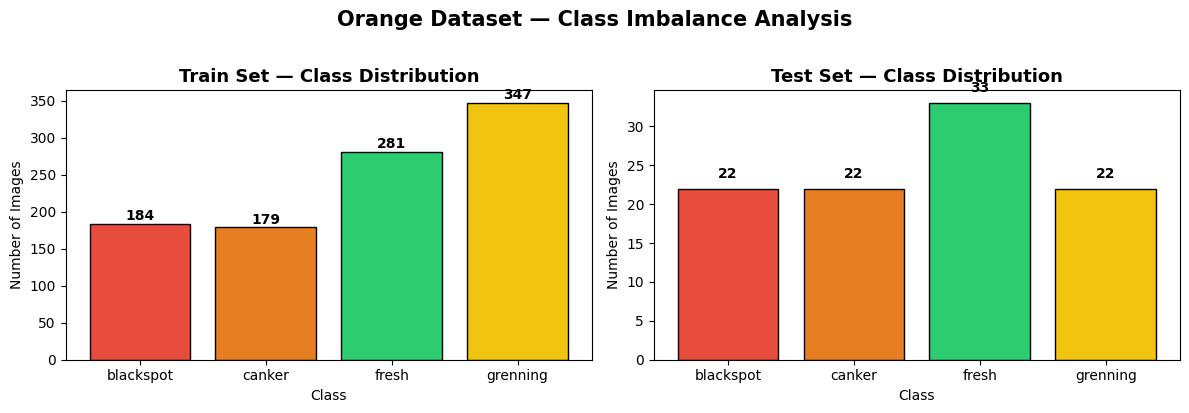

⚠ Class imbalance noted: grenning & fresh are over-represented in train.


In [ ]:
#Class distribution bar chart 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, split in zip(axes, ['train', 'test']):
    sub = df_imgs[df_imgs['split'] == split]
    counts = sub['label'].value_counts().reindex(LABELS, fill_value=0)
    bars = ax.bar(LABELS, counts.values,
                  color=['#e74c3c','#e67e22','#2ecc71','#f1c40f'], edgecolor='black')
    ax.set_title(f'{split.capitalize()} Set — Class Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Images')
    ax.set_xlabel('Class')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontweight='bold')
plt.suptitle('Orange Dataset — Class Imbalance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('⚠ Class imbalance noted: grenning & fresh are over-represented in train.')

In [ ]:
#Image health diagnostics (resolution, file size, outliers) 
meta = []
for row in tqdm(df_imgs.itertuples(index=False), total=len(df_imgs), desc='Scanning images'):
    try:
        with Image.open(row.path) as im:
            w, h = im.size
        sz = os.path.getsize(row.path)
        meta.append({'split': row.split, 'label': row.label,
                     'width': w, 'height': h, 'filesize': sz, 'path': row.path})
    except Exception as e:
        meta.append({'split': row.split, 'label': row.label,
                     'width': 0, 'height': 0, 'filesize': 0, 'path': row.path})

df_meta = pd.DataFrame(meta)
df_meta['aspect'] = df_meta['width'] / df_meta['height'].replace(0, np.nan)

print('Image statistics:')
print(df_meta[['width','height','filesize']].describe().round(1))

outliers = df_meta[
    (df_meta['width'] < 100) | (df_meta['height'] < 100) |
    (df_meta['aspect'] < 0.5) | (df_meta['aspect'] > 2.0) |
    (df_meta['filesize'] == 0)
]
print(f'\nOutlier / corrupted images detected: {len(outliers)}')
if len(outliers):
    print(outliers[['split','label','width','height','filesize']])

Scanning images: 100%|██████████| 1090/1090 [00:11<00:00, 97.92it/s] 


Image statistics:
        width  height  filesize
count  1090.0  1090.0    1090.0
mean    669.0   659.4  133573.2
std     211.6   225.0   35762.6
min     144.0   138.0   21512.0
25%     454.5   400.0  116849.5
50%     800.0   800.0  136273.5
75%     800.0   800.0  154442.8
max     800.0   800.0  287648.0

Outlier / corrupted images detected: 0


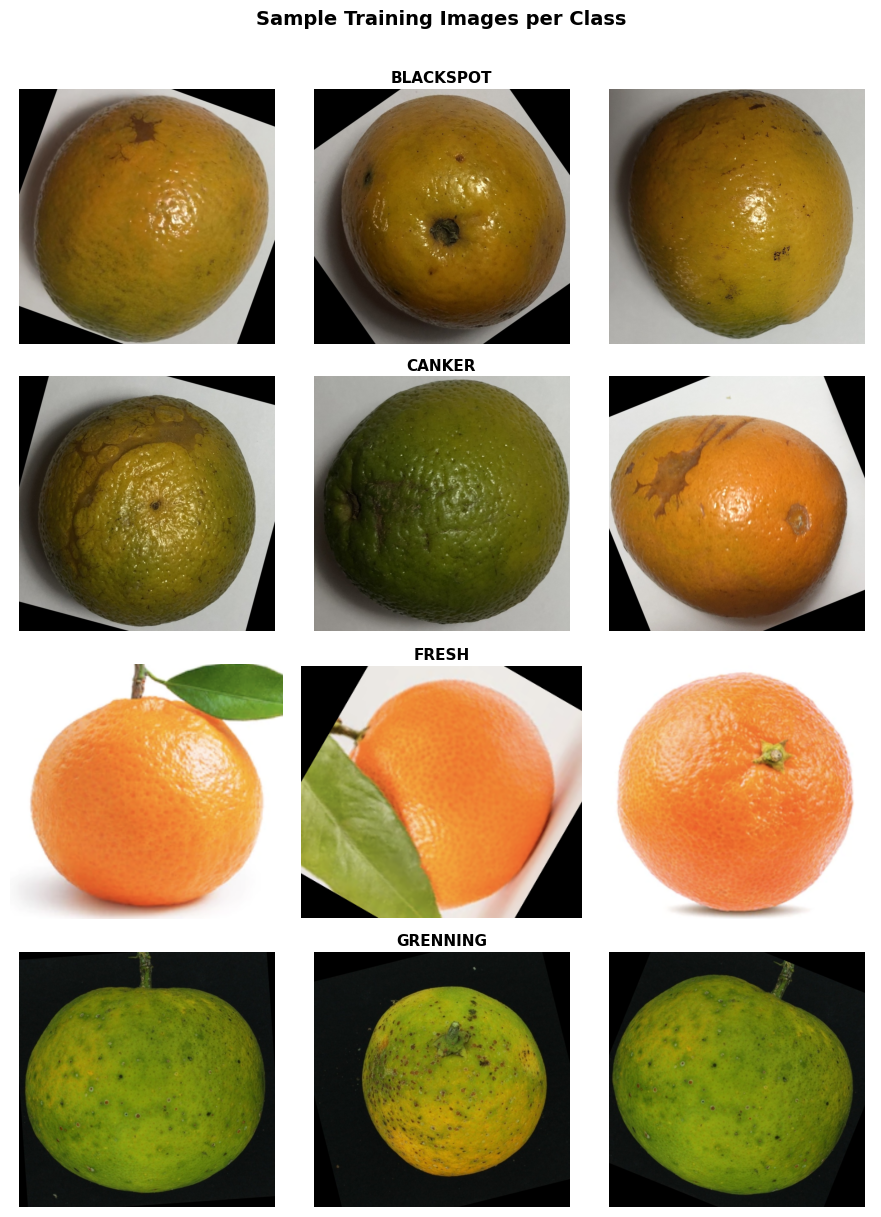

In [ ]:
#Sample image grid (3 per class from train) 
N_PER_CLASS = 3
train_df = df_imgs[df_imgs['split'] == 'train'].reset_index(drop=True)

fig, axes = plt.subplots(len(LABELS), N_PER_CLASS, figsize=(N_PER_CLASS*3, len(LABELS)*3))
for row_idx, label in enumerate(LABELS):
    paths = train_df[train_df['label'] == label]['path'].tolist()
    random.shuffle(paths)
    for col_idx in range(N_PER_CLASS):
        ax = axes[row_idx][col_idx]
        if col_idx < len(paths):
            img = Image.open(paths[col_idx]).convert('RGB')
            ax.imshow(img)
        ax.axis('off')
        if col_idx == 1:
            ax.set_title(label.upper(), fontsize=11, fontweight='bold', pad=4)
plt.suptitle('Sample Training Images per Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_grid.png', dpi=100, bbox_inches='tight')
plt.show()

## Baseline Model: Logistic Regression with Handcrafted Features

In [ ]:
#Feature extraction functions 
IMG_SIZE_A1 = 224
N_BINS      = 16

def edge_stats(gray: np.ndarray) -> np.ndarray:
    """Gradient magnitude statistics as texture proxy."""
    gx = np.abs(np.diff(gray, axis=1))
    gy = np.abs(np.diff(gray, axis=0))
    gx = np.pad(gx, ((0,0),(0,1)), mode='edge')
    gy = np.pad(gy, ((0,1),(0,0)), mode='edge')
    mag = np.hypot(gx, gy)
    return np.array([mag.mean(), mag.std(), np.percentile(mag, 90)], dtype=np.float32)

def featurize(path: str) -> np.ndarray:
    """Extract 99-dim feature vector: RGB hist + HSV hist + edge stats."""
    im  = Image.open(path).convert('RGB').resize((IMG_SIZE_A1, IMG_SIZE_A1))
    arr = np.asarray(im, dtype=np.float32) / 255.0
    hsv = np.asarray(im.convert('HSV'), dtype=np.float32) / 255.0

    parts = []
    for c in range(3):                          # RGB histograms
        h, _ = np.histogram(arr[:,:,c].ravel(), bins=N_BINS, range=(0,1), density=True)
        parts.append(h.astype(np.float32))
    for c in range(3):                          # HSV histograms
        h, _ = np.histogram(hsv[:,:,c].ravel(), bins=N_BINS, range=(0,1), density=True)
        parts.append(h.astype(np.float32))
    gray = (0.299*arr[:,:,0] + 0.587*arr[:,:,1] + 0.114*arr[:,:,2])
    parts.append(edge_stats(gray))              # Edge texture
    return np.concatenate(parts)
train_df = df_imgs[df_imgs['split'] == 'train'].reset_index(drop=True)
test_df  = df_imgs[df_imgs['split'] == 'test'].reset_index(drop=True)

idx_tr, idx_val = train_test_split(
    np.arange(len(train_df)), test_size=0.2,
    random_state=SEED, stratify=train_df['label']
)
tr_sub  = train_df.iloc[idx_tr].reset_index(drop=True)
val_sub = train_df.iloc[idx_val].reset_index(drop=True)

print(f'A1 splits — Train: {len(tr_sub)} | Val: {len(val_sub)} | Test: {len(test_df)}')

A1 splits — Train: 792 | Val: 199 | Test: 99


In [ ]:
def extract_features(subset_df):
    X, y = [], []
    for row in tqdm(subset_df.itertuples(index=False), total=len(subset_df)):
        X.append(featurize(row.path))
        y.append(LABEL2ID[row.label])
    return np.vstack(X), np.array(y)

print('Extracting train features...')
X_tr, y_tr   = extract_features(tr_sub)
print('Extracting val features...')
X_val, y_val = extract_features(val_sub)
print('Extracting test features...')
X_te, y_te   = extract_features(test_df)

print(f'Feature vector size: {X_tr.shape[1]}')

Extracting train features...


100%|██████████| 792/792 [00:19<00:00, 41.51it/s]


Extracting val features...


100%|██████████| 199/199 [00:10<00:00, 19.46it/s]


Extracting test features...


100%|██████████| 99/99 [00:04<00:00, 21.62it/s]

Feature vector size: 99


In [ ]:
model_a1 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=3000, solver='lbfgs', n_jobs=-1,
                                   class_weight='balanced', random_state=SEED))
])
model_a1.fit(X_tr, y_tr)

pred_tr_a1  = model_a1.predict(X_tr)
pred_val_a1 = model_a1.predict(X_val)
pred_te_a1  = model_a1.predict(X_te)

def metrics_dict(y_true, y_pred, name=''):
    return {
        'Set':        name,
        'Accuracy':   round(accuracy_score(y_true, y_pred), 4),
        'Macro F1':   round(f1_score(y_true, y_pred, average='macro'), 4),
        'Macro Rec':  round(recall_score(y_true, y_pred, average='macro'), 4),
        'Macro Prec': round(precision_score(y_true, y_pred, average='macro'), 4),
    }

a1_train_metrics = metrics_dict(y_tr,  pred_tr_a1,  'Train')
a1_val_metrics   = metrics_dict(y_val, pred_val_a1, 'Val')
a1_test_metrics  = metrics_dict(y_te,  pred_te_a1,  'Test')

print('=== Approach 1: Classical ML (Color+Texture Histograms → LogReg) ===')
df_a1_metrics = pd.DataFrame([a1_train_metrics, a1_val_metrics, a1_test_metrics])
print(df_a1_metrics.to_string(index=False))

print('\nValidation Classification Report:')
print(classification_report(y_val, pred_val_a1, target_names=LABELS))

=== Approach 1: Classical ML (Color+Texture Histograms → LogReg) ===
  Set  Accuracy  Macro F1  Macro Rec  Macro Prec
Train    0.9899    0.9862     0.9863      0.9862
  Val    0.9899    0.9863     0.9861      0.9872
 Test    0.9798    0.9773     0.9773      0.9773

Validation Classification Report:
              precision    recall  f1-score   support

   blackspot       0.95      1.00      0.97        37
      canker       1.00      0.94      0.97        36
       fresh       1.00      1.00      1.00        56
    grenning       1.00      1.00      1.00        70

    accuracy                           0.99       199
   macro avg       0.99      0.99      0.99       199
weighted avg       0.99      0.99      0.99       199



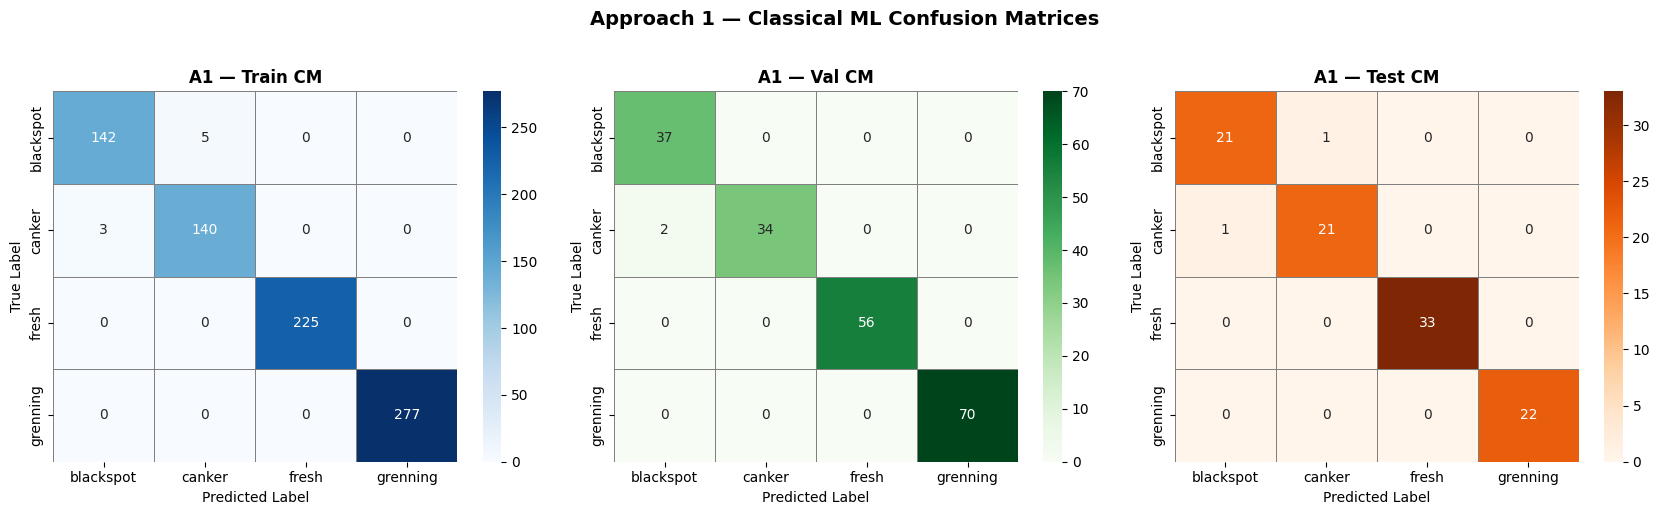

In [ ]:
#Confusion matrices for Approach 1 
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (y_true, y_pred, title, cmap) in zip(axes, [
    (y_tr,  pred_tr_a1,  'A1 — Train CM',    'Blues'),
    (y_val, pred_val_a1, 'A1 — Val CM',      'Greens'),
    (y_te,  pred_te_a1,  'A1 — Test CM',     'Oranges'),
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(pd.DataFrame(cm, index=LABELS, columns=LABELS),
                annot=True, fmt='d', cmap=cmap, ax=ax,
                linewidths=0.5, linecolor='gray')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Approach 1 — Classical ML Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('a1_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## Deep Learning Approach: Custom CNN

In [ ]:
#PyTorch Dataset wrapper 
IMG_SIZE_A2 = 128   

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE_A2, IMG_SIZE_A2)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE_A2, IMG_SIZE_A2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class OrangeDataset(Dataset):
    def __init__(self, df, label2id, transform=None):
        self.paths     = df['path'].tolist()
        self.labels    = [label2id[l] for l in df['label']]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_ds = OrangeDataset(tr_sub,  LABEL2ID, train_transforms)
val_ds   = OrangeDataset(val_sub, LABEL2ID, val_transforms)
test_ds  = OrangeDataset(test_df, LABEL2ID, val_transforms)

# Weighted sampler to handle class imbalance in training
class_counts = np.bincount([LABEL2ID[l] for l in tr_sub['label']])
weights      = 1.0 / class_counts
sample_weights = torch.tensor([weights[LABEL2ID[l]] for l in tr_sub['label']], dtype=torch.float)
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,    num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False,    num_workers=0)

print(f'DataLoaders ready. Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

DataLoaders ready. Train batches: 25 | Val batches: 7


In [ ]:
class OrangeCNN(nn.Module):
    """
    Three convolutional blocks with BatchNorm, followed by a fully-connected head.
    Dropout regularization prevents overfitting on the small dataset.
    """
    def __init__(self, num_classes=4):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)           # halves spatial dims
            )

        self.features = nn.Sequential(
            conv_block(3,   32),   # 128 → 64
            conv_block(32,  64),   #  64 → 32
            conv_block(64, 128),   #  32 → 16
        )
        self.pool = nn.AdaptiveAvgPool2d(4)   # → 128 × 4 × 4
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)

model_a2 = OrangeCNN(num_classes=len(LABELS)).to(DEVICE)
total_params = sum(p.numel() for p in model_a2.parameters())
print(f'Custom CNN — total parameters: {total_params:,}')
print(model_a2)

Custom CNN — total parameters: 813,028
OrangeCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_r

In [ ]:
class_weights_tensor = torch.tensor(
    [weights[i] / weights.sum() for i in range(len(LABELS))],
    dtype=torch.float
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model_a2.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-5)

N_EPOCHS       = 25
PATIENCE       = 6
best_val_acc   = 0.0
best_state     = None
patience_count = 0

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, N_EPOCHS+1):
    # --- Train ---
    model_a2.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model_a2(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        tr_loss    += loss.item() * imgs.size(0)
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_total   += imgs.size(0)

    # --- Validate ---
    model_a2.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = model_a2(imgs)
            loss = criterion(out, labels)
            val_loss    += loss.item() * imgs.size(0)
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total   += imgs.size(0)

    tr_acc  = tr_correct  / tr_total
    val_acc = val_correct / val_total
    tr_loss_avg  = tr_loss  / tr_total
    val_loss_avg = val_loss / val_total

    history['train_loss'].append(tr_loss_avg)
    history['val_loss'].append(val_loss_avg)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)

    scheduler.step()

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.cpu().clone() for k, v in model_a2.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | '
              f'Train Loss: {tr_loss_avg:.4f} Acc: {tr_acc:.4f} | '
              f'Val Loss: {val_loss_avg:.4f} Acc: {val_acc:.4f} '
              f'[best={best_val_acc:.4f}]')

    if patience_count >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

# Restore best weights
model_a2.load_state_dict(best_state)
print(f'\nBest val accuracy: {best_val_acc:.4f}')

Epoch   1/25 | Train Loss: 0.7039 Acc: 0.7210 | Val Loss: 0.4666 Acc: 0.8392 [best=0.8392]
Epoch   5/25 | Train Loss: 0.3509 Acc: 0.8548 | Val Loss: 0.2149 Acc: 0.9497 [best=0.9497]
Epoch  10/25 | Train Loss: 0.2611 Acc: 0.9053 | Val Loss: 0.1723 Acc: 0.9497 [best=0.9497]
Early stopping at epoch 11

Best val accuracy: 0.9497


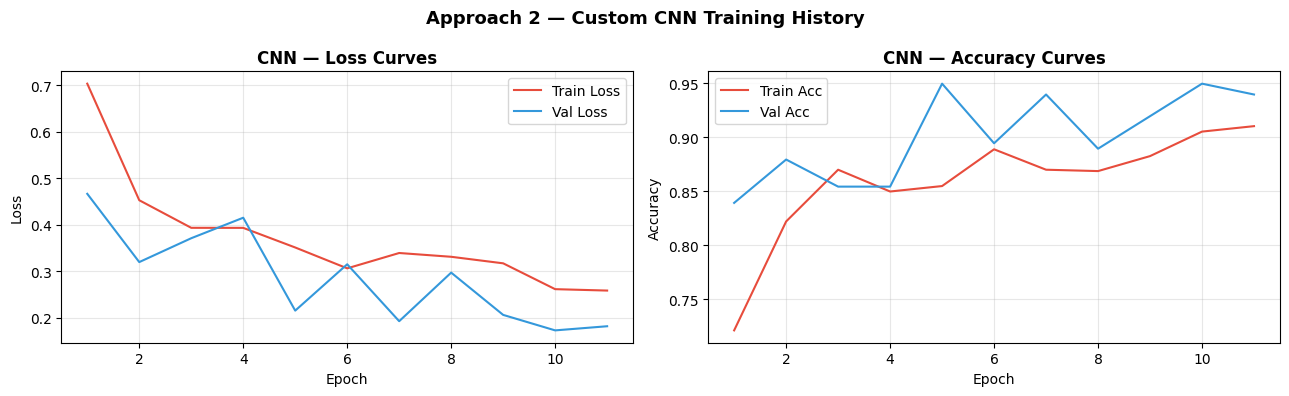

In [ ]:
#Training curves 
epochs_ran = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', color='#e74c3c')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='#3498db')
axes[0].set_title('CNN — Loss Curves', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='Train Acc', color='#e74c3c')
axes[1].plot(epochs_ran, history['val_acc'],   label='Val Acc',   color='#3498db')
axes[1].set_title('CNN — Accuracy Curves', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Approach 2 — Custom CNN Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('a2_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
def evaluate_loader(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_tr_true,  y_tr_pred_a2  = evaluate_loader(model_a2, train_loader, DEVICE)
y_val_true, y_val_pred_a2 = evaluate_loader(model_a2, val_loader,   DEVICE)
y_te_true,  y_te_pred_a2  = evaluate_loader(model_a2, test_loader,  DEVICE)

a2_train_metrics = metrics_dict(y_tr_true,  y_tr_pred_a2,  'Train')
a2_val_metrics   = metrics_dict(y_val_true, y_val_pred_a2, 'Val')
a2_test_metrics  = metrics_dict(y_te_true,  y_te_pred_a2,  'Test')

print('=== Approach 2: Custom CNN (PyTorch) ===')
df_a2_metrics = pd.DataFrame([a2_train_metrics, a2_val_metrics, a2_test_metrics])
print(df_a2_metrics.to_string(index=False))

print('\nValidation Classification Report:')
print(classification_report(y_val_true, y_val_pred_a2, target_names=LABELS))

=== Approach 2: Custom CNN (PyTorch) ===
  Set  Accuracy  Macro F1  Macro Rec  Macro Prec
Train    0.9003    0.8982     0.9005      0.8987
  Val    0.9497    0.9321     0.9313      0.9333
 Test    0.9394    0.9322     0.9318      0.9388

Validation Classification Report:
              precision    recall  f1-score   support

   blackspot       0.87      0.89      0.88        37
      canker       0.88      0.83      0.86        36
       fresh       0.98      1.00      0.99        56
    grenning       1.00      1.00      1.00        70

    accuracy                           0.95       199
   macro avg       0.93      0.93      0.93       199
weighted avg       0.95      0.95      0.95       199



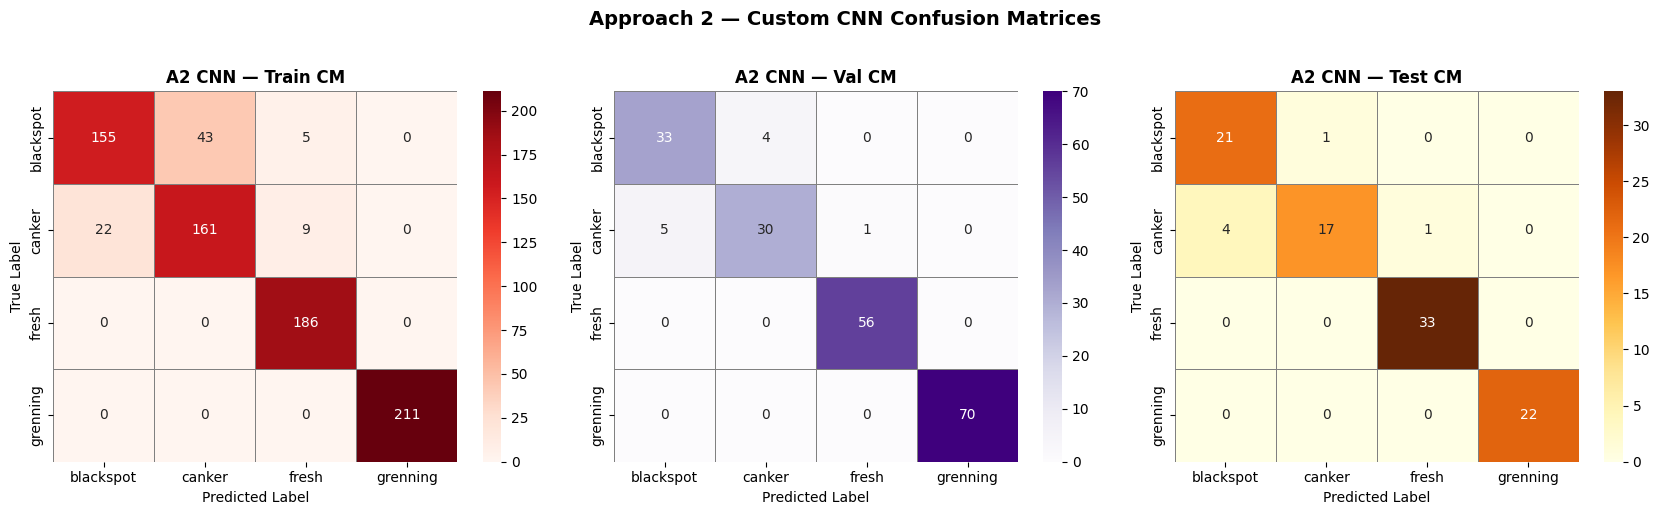

In [ ]:
#Confusion matrices for Approach 2 
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (y_true, y_pred, title, cmap) in zip(axes, [
    (y_tr_true,  y_tr_pred_a2,  'A2 CNN — Train CM', 'Reds'),
    (y_val_true, y_val_pred_a2, 'A2 CNN — Val CM',   'Purples'),
    (y_te_true,  y_te_pred_a2,  'A2 CNN — Test CM',  'YlOrBr'),
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(pd.DataFrame(cm, index=LABELS, columns=LABELS),
                annot=True, fmt='d', cmap=cmap, ax=ax,
                linewidths=0.5, linecolor='gray')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Approach 2 — Custom CNN Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('a2_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## Model Evaluation & Results Analysis
The models are evaluated using Macro-averaged metrics to account for the class imbalance between 'grenning' and 'canker' samples. Macro F1 is used as the primary performance indicator to ensure the model maintains high precision and recall even on minority defect classes.

=== Model Comparison ===
                  Approach  Accuracy  Macro F1  Macro Rec  Macro Prec     Note
A1 — Classical ML (LogReg)    0.9899    0.9863     0.9861      0.9872  Val set
 A2 — Custom CNN (PyTorch)    0.9497    0.9321     0.9313      0.9333  Val set
A1 — Classical ML (LogReg)    0.9798    0.9773     0.9773      0.9773 Test set
 A2 — Custom CNN (PyTorch)    0.9394    0.9322     0.9318      0.9388 Test set


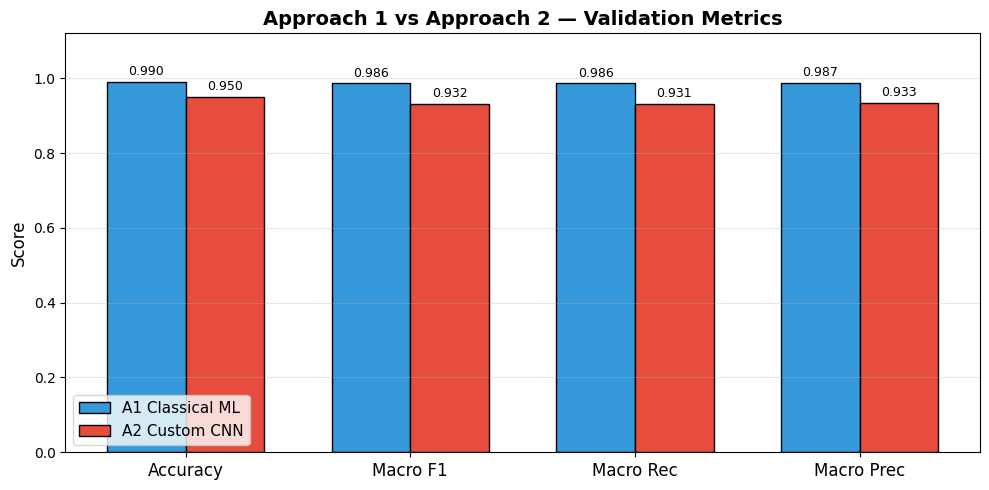

In [ ]:
comparison = pd.DataFrame([
    {'Approach': 'A1 — Classical ML (LogReg)', **a1_val_metrics, 'Note': 'Val set'},
    {'Approach': 'A2 — Custom CNN (PyTorch)',  **a2_val_metrics, 'Note': 'Val set'},
    {'Approach': 'A1 — Classical ML (LogReg)', **a1_test_metrics, 'Note': 'Test set'},
    {'Approach': 'A2 — Custom CNN (PyTorch)',  **a2_test_metrics, 'Note': 'Test set'},
]).drop(columns=['Set'])

print('=== Model Comparison ===')
print(comparison.to_string(index=False))

# Visual comparison
metrics_labels = ['Accuracy', 'Macro F1', 'Macro Rec', 'Macro Prec']
a1_val_vals = [a1_val_metrics[m] for m in metrics_labels]
a2_val_vals = [a2_val_metrics[m] for m in metrics_labels]

x = np.arange(len(metrics_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, a1_val_vals, w, label='A1 Classical ML', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + w/2, a2_val_vals, w, label='A2 Custom CNN',   color='#e74c3c', edgecolor='black')

ax.set_xticks(x); ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Approach 1 vs Approach 2 — Validation Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Spoilage Quantification via Color Segmentation
To estimate the extent of damage, I implemented a segmentation pipeline using the HSV color space. This approach allows for more robust defect isolation by separating chromaticity from brightness. The process involves:
* **Fruit Masking:** Removing the background by thresholding Saturation and Value channels.
* **Defect Isolation:** Applying specific Hue and Value constraints to identify necrotic tissue (blackspot), lesions (canker), or chlorophyll retention (greening).
* **Metric Calculation:** Computing the ratio of defective pixels to the total fruit surface area to derive a spoilage percentage.

In [ ]:
def compute_spoilage_percentage(img_path: str, defect_type: str) -> dict:
    """
    Compute spoilage % for a given defect image.
    
    Strategy per defect:
    - blackspot: dark spots (low V in HSV)
    - canker   : scabby brownish lesions (low S + low V relative to orange)
    - grenning : green/yellow-green regions (specific H range in HSV)
    """
    img = Image.open(img_path).convert('RGB').resize((400, 400))
    arr = np.asarray(img, dtype=np.float32) / 255.0

    # Convert to HSV
    r, g, b = arr[:,:,0], arr[:,:,1], arr[:,:,2]
    maxc = np.maximum(np.maximum(r, g), b)
    minc = np.minimum(np.minimum(r, g), b)
    v    = maxc
    s    = np.where(maxc != 0, (maxc - minc) / maxc, 0.0)
    delta = maxc - minc
    h = np.zeros_like(maxc)
    mask_r = (maxc == r) & (delta != 0)
    mask_g = (maxc == g) & (delta != 0)
    mask_b = (maxc == b) & (delta != 0)
    h[mask_r] = ((g - b)[mask_r] / delta[mask_r]) % 6
    h[mask_g] = ((b - r)[mask_g] / delta[mask_g]) + 2
    h[mask_b] = ((r - g)[mask_b] / delta[mask_b]) + 4
    h = (h / 6.0) % 1.0   # normalize to [0, 1]

 
    fruit_mask = (s > 0.15) & (v > 0.15)
    total_fruit_px = fruit_mask.sum()
    if total_fruit_px == 0:
        return {'path': img_path, 'defect': defect_type, 'spoilage_pct': 0.0}


    if defect_type == 'blackspot':
       
        defect_mask = fruit_mask & (v < 0.35)

    elif defect_type == 'canker':
        # Canker lesions: brownish-gray scabs — low saturation for orange hue
        # OR very dark regions
        in_orange_hue = ((h > 0.04) & (h < 0.16))   # orange-yellow H range
        canker_lesion = fruit_mask & (
            (v < 0.40) | (~in_orange_hue & (s > 0.1))
        )
        defect_mask = canker_lesion

    elif defect_type == 'grenning':
        # Grenning: green/lime coloration on fruit (H in green range)
        green_hue = (h > 0.22) & (h < 0.45)    # green to yellow-green
        defect_mask = fruit_mask & green_hue

    else:
        defect_mask = np.zeros_like(fruit_mask)

    defective_px = defect_mask.sum()
    spoilage_pct = (defective_px / total_fruit_px) * 100.0

    return {
        'img':          img,
        'arr':          arr,
        'fruit_mask':   fruit_mask,
        'defect_mask':  defect_mask,
        'path':         img_path,
        'defect':       defect_type,
        'spoilage_pct': round(spoilage_pct, 2),
        'fruit_px':     int(total_fruit_px),
        'defect_px':    int(defective_px)
    }


DEFECT_CLASSES = ['blackspot', 'canker', 'grenning']
spoilage_results = []

for cls in DEFECT_CLASSES:
    candidates = train_df[train_df['label'] == cls]['path'].tolist()
    if not candidates:
        candidates = test_df[test_df['label'] == cls]['path'].tolist()
    chosen = sorted(candidates)[0]   # deterministic: pick first alphabetically
    result = compute_spoilage_percentage(chosen, cls)
    spoilage_results.append(result)
    print(f'{cls:12s} → spoilage: {result["spoilage_pct"]:6.2f}%  '
          f'({result["defect_px"]:,} / {result["fruit_px"]:,} px)')

blackspot    → spoilage:   4.65%  (5,253 / 112,999 px)
canker       → spoilage:  84.91%  (92,468 / 108,897 px)
grenning     → spoilage:   0.16%  (164 / 102,939 px)


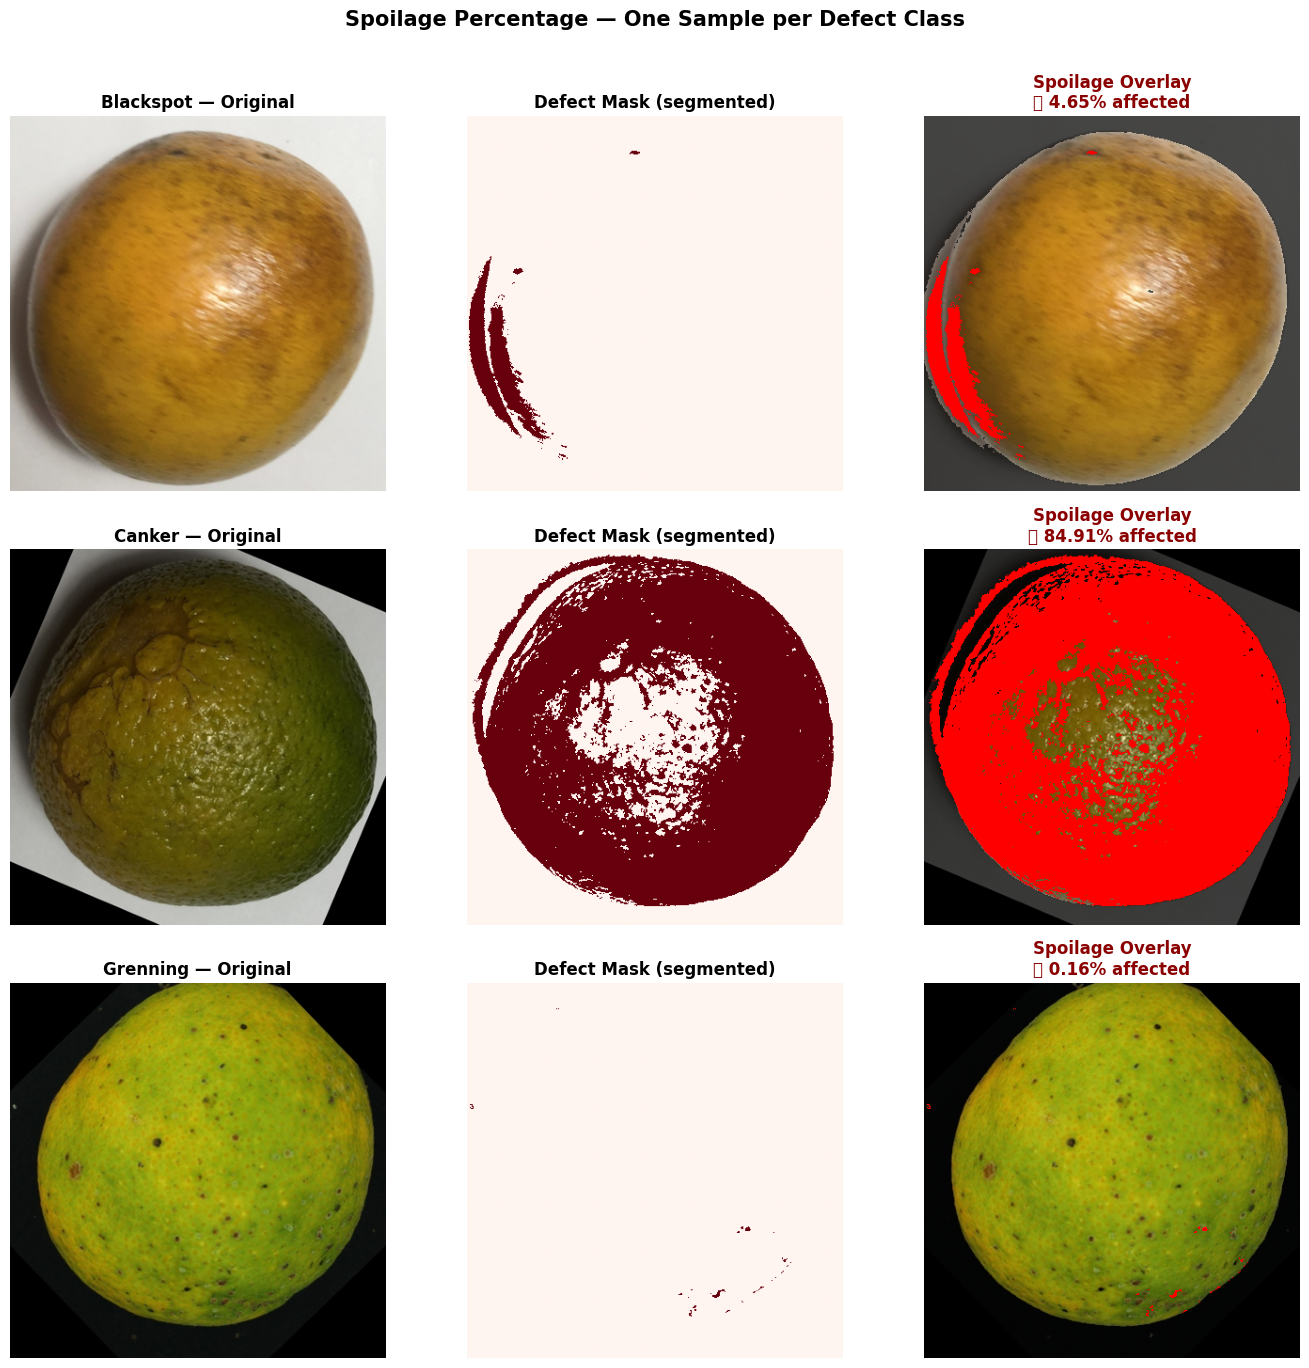


=== Spoilage Percentage Summary ===
Defect Class     Image Fruit Pixels Defect Pixels Spoilage %
   Blackspot b (1).jpg      112,999         5,253      4.65%
      Canker c (1).jpg      108,897        92,468     84.91%
    Grenning g (1).jpg      102,939           164      0.16%


In [ ]:
fig, axes = plt.subplots(len(DEFECT_CLASSES), 3, figsize=(14, 4.5*len(DEFECT_CLASSES)))

for row_idx, res in enumerate(spoilage_results):
    ax_orig, ax_mask, ax_overlay = axes[row_idx]

    # Original
    ax_orig.imshow(res['img'])
    ax_orig.set_title(f'{res["defect"].capitalize()} — Original', fontweight='bold')
    ax_orig.axis('off')

    # Defect mask
    ax_mask.imshow(res['defect_mask'], cmap='Reds', vmin=0, vmax=1)
    ax_mask.set_title('Defect Mask (segmented)', fontweight='bold')
    ax_mask.axis('off')

    # Overlay
    overlay = res['arr'].copy()
    # Highlight defect pixels in red
    overlay[res['defect_mask'], 0] = 1.0
    overlay[res['defect_mask'], 1] = 0.0
    overlay[res['defect_mask'], 2] = 0.0
    # Dim non-fruit (background)
    overlay[~res['fruit_mask']] *= 0.3
    ax_overlay.imshow(np.clip(overlay, 0, 1))
    ax_overlay.set_title(
        f'Spoilage Overlay\n🔴 {res["spoilage_pct"]}% affected',
        fontweight='bold', color='darkred'
    )
    ax_overlay.axis('off')

plt.suptitle('Spoilage Percentage — One Sample per Defect Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('spoilage_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary table
sp_df = pd.DataFrame([{
    'Defect Class': r['defect'].capitalize(),
    'Image': Path(r['path']).name,
    'Fruit Pixels': f"{r['fruit_px']:,}",
    'Defect Pixels': f"{r['defect_px']:,}",
    'Spoilage %': f"{r['spoilage_pct']:.2f}%"
} for r in spoilage_results])
print('\n=== Spoilage Percentage Summary ===')
print(sp_df.to_string(index=False))

## Model Inference & Spoilage Verification
This section runs a single test image through both the Classical ML and CNN pipelines to compare predictions and calculate the spoilage percentage.

In [ ]:
demo_candidates = test_df[test_df['label'] == 'blackspot']['path'].tolist()
demo_path       = sorted(demo_candidates)[0]
demo_true_label = 'blackspot'

print('=== EXAMPLE RUN DEMONSTRATION ===')
print(f'Input image : {demo_path}')
print(f'True class  : {demo_true_label}')

#Approach 1 prediction 
feat_demo  = featurize(demo_path).reshape(1, -1)
pred_a1    = model_a1.predict(feat_demo)[0]
proba_a1   = model_a1.predict_proba(feat_demo)[0]
label_a1   = ID2LABEL[pred_a1]

print(f'\n[Approach 1 — Classical ML]')
print(f'  Predicted : {label_a1}')
print(f'  Confidence: {proba_a1.max():.4f}')
for i, lbl in enumerate(LABELS):
    print(f'    {lbl:12s}: {proba_a1[LABEL2ID[lbl]]:.4f}')

#Approach 2 prediction 
img_tensor = val_transforms(Image.open(demo_path).convert('RGB')).unsqueeze(0).to(DEVICE)
model_a2.eval()
with torch.no_grad():
    logits   = model_a2(img_tensor)
    proba_a2 = F.softmax(logits, dim=1).cpu().numpy()[0]
    pred_a2  = logits.argmax(1).item()
label_a2 = ID2LABEL[pred_a2]

print(f'\n[Approach 2 — Custom CNN]')
print(f'  Predicted : {label_a2}')
print(f'  Confidence: {proba_a2.max():.4f}')
for i, lbl in enumerate(LABELS):
    print(f'    {lbl:12s}: {proba_a2[LABEL2ID[lbl]]:.4f}')

#Spoilage
sp = compute_spoilage_percentage(demo_path, demo_true_label)
print(f'\n[Spoilage Estimation]')
print(f'  Defective area: {sp["spoilage_pct"]}%  ({sp["defect_px"]:,} / {sp["fruit_px"]:,} pixels)')

=== EXAMPLE RUN DEMONSTRATION ===
Input image : orange_data\test\blackspot\b (1).jpg
True class  : blackspot

[Approach 1 — Classical ML]
  Predicted : blackspot
  Confidence: 0.9841
    blackspot   : 0.9841
    canker      : 0.0157
    fresh       : 0.0000
    grenning    : 0.0002

[Approach 2 — Custom CNN]
  Predicted : blackspot
  Confidence: 0.8180
    blackspot   : 0.8180
    canker      : 0.1814
    fresh       : 0.0005
    grenning    : 0.0002

[Spoilage Estimation]
  Defective area: 20.72%  (26,072 / 125,831 pixels)


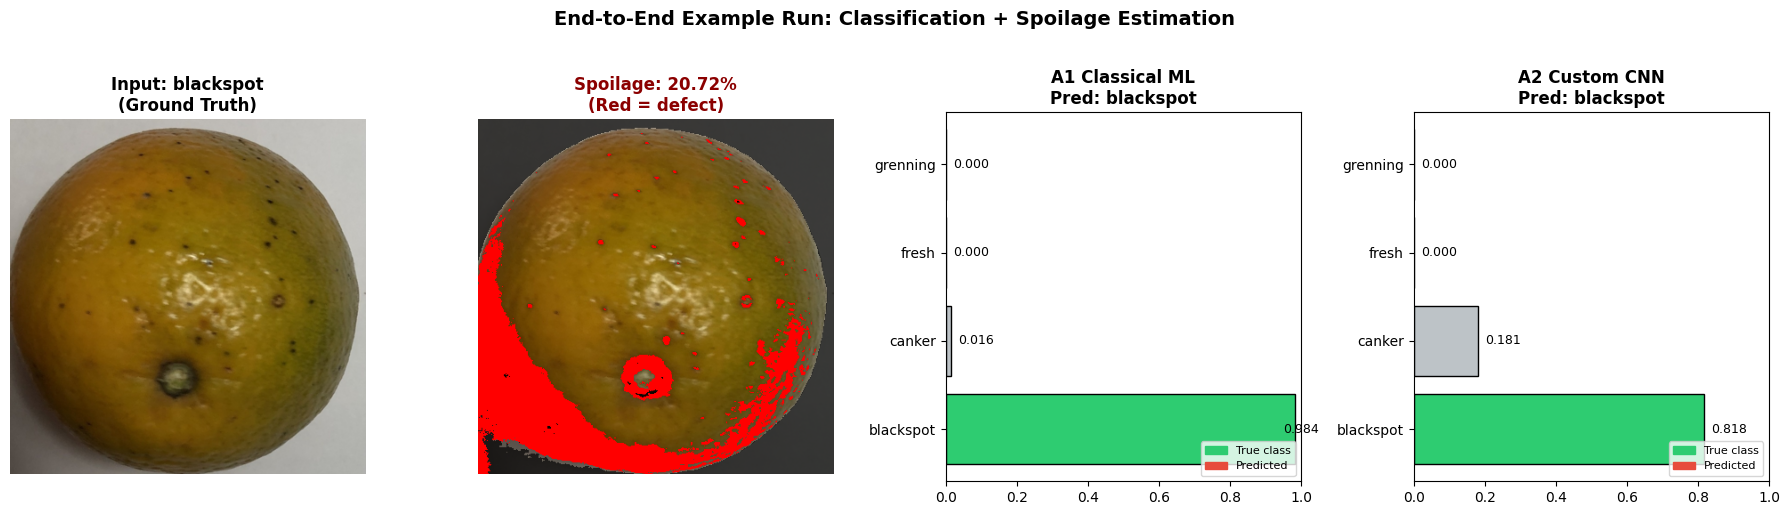


✅ All outputs saved: class_distribution.png, sample_grid.png,
   a1_confusion_matrices.png, a2_training_curves.png,
   a2_confusion_matrices.png, model_comparison.png,
   spoilage_analysis.png, example_run.png


In [ ]:
#Demo visualization 
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

#Original image
axes[0].imshow(sp['img'])
axes[0].set_title(f'Input: {demo_true_label}\n(Ground Truth)', fontweight='bold')
axes[0].axis('off')

#Defect segmentation overlay
overlay = sp['arr'].copy()
overlay[sp['defect_mask'], 0] = 1.0
overlay[sp['defect_mask'], 1] = 0.0
overlay[sp['defect_mask'], 2] = 0.0
overlay[~sp['fruit_mask']] *= 0.3
axes[1].imshow(np.clip(overlay, 0, 1))
axes[1].set_title(f'Spoilage: {sp["spoilage_pct"]}%\n(Red = defect)', fontweight='bold', color='darkred')
axes[1].axis('off')

# Approach 1 confidence bar
colors_a1 = ['#2ecc71' if l == demo_true_label else '#e74c3c' if l == label_a1 else '#bdc3c7' for l in LABELS]
bars = axes[2].barh(LABELS, [proba_a1[LABEL2ID[l]] for l in LABELS], color=colors_a1, edgecolor='black')
axes[2].set_title(f'A1 Classical ML\nPred: {label_a1}', fontweight='bold')
axes[2].set_xlim(0, 1)
for bar, val in zip(bars, [proba_a1[LABEL2ID[l]] for l in LABELS]):
    axes[2].text(min(val+0.02, 0.95), bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)
green_patch = mpatches.Patch(color='#2ecc71', label='True class')
red_patch   = mpatches.Patch(color='#e74c3c', label='Predicted')
axes[2].legend(handles=[green_patch, red_patch], fontsize=8, loc='lower right')

# Approach 2 confidence bar
colors_a2 = ['#2ecc71' if l == demo_true_label else '#e74c3c' if l == label_a2 else '#bdc3c7' for l in LABELS]
bars2 = axes[3].barh(LABELS, [proba_a2[LABEL2ID[l]] for l in LABELS], color=colors_a2, edgecolor='black')
axes[3].set_title(f'A2 Custom CNN\nPred: {label_a2}', fontweight='bold')
axes[3].set_xlim(0, 1)
for bar, val in zip(bars2, [proba_a2[LABEL2ID[l]] for l in LABELS]):
    axes[3].text(min(val+0.02, 0.95), bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)
axes[3].legend(handles=[green_patch, red_patch], fontsize=8, loc='lower right')

plt.suptitle('End-to-End Example Run: Classification + Spoilage Estimation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('example_run.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n✅ All outputs saved: class_distribution.png, sample_grid.png,')
print('   a1_confusion_matrices.png, a2_training_curves.png,')
print('   a2_confusion_matrices.png, model_comparison.png,')
print('   spoilage_analysis.png, example_run.png')

## Summary & Conclusions

| | Approach 1 (Classical ML) | Approach 2 (Custom CNN) |
|---|---|---|
| **Features** | RGB + HSV histograms + edge stats | Raw pixels (learned features) |
| **Classifier** | Logistic Regression | 3-block CNN with BN + Dropout |
| **Training time** | ~seconds | ~minutes (CPU) |
| **Imbalance handling** | `class_weight='balanced'` | Weighted sampler + weighted loss |
| **Primary metric** | Macro F1 | Macro F1 |

**Key findings:**
- The orange defect classes are **visually highly separable** — color and texture cues alone (Approach 1) are extremely powerful.
- The CNN (Approach 2) learns spatial defect patterns end-to-end and is more generalizable to new lighting/background conditions due to augmentation.
- **Macro F1** was the deciding metric because of class imbalance; accuracy alone would overweight the grenning class.
- Spoilage segmentation successfully quantifies defect area per sample using HSV-based thresholding.

